# CRMLS Sold Data Analysis

In [14]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

## Monthly Dataset Aggregation

In [15]:
# Get all CRMLSSold files
sold_data = glob.glob('**/CRMLSSold*.csv',recursive=True)

df_list = []
for file in sold_data:
    df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)
    print(f"Rows before aggregation: {len(df)}")
    df_list.append(df)
sold_df = pd.concat(df_list, ignore_index=True)

print(f'Rows after aggregation: {len(sold_df)}')

# Filter to residential
print(f"Rows before Residential Filter: {len(sold_df)}")
sold_df = sold_df[sold_df['PropertyType'] == "Residential"]
print(f"Rows after Residential Filter: {len(sold_df)}")

# Save to csv 
# sold_df.to_csv('CRMLSSoldResidential.csv', index=False)

C:\Users\caden\AppData\Local\Temp\ipykernel_8824\602667860.py:6: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: FireplaceYN, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)


Rows before aggregation: 1102758
Rows before aggregation: 7000
Rows before aggregation: 7000
Rows before aggregation: 17976
Rows before aggregation: 19925
Rows before aggregation: 23276
Rows before aggregation: 24640


C:\Users\caden\AppData\Local\Temp\ipykernel_8824\602667860.py:6: DtypeWarning: Columns (0: WaterfrontYN, 1: ElementarySchool, 2: BuilderName, 3: CoBuyerAgentFirstName, 4: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)


Rows before aggregation: 26487
Rows before aggregation: 24328
Rows before aggregation: 26240
Rows before aggregation: 24558
Rows before aggregation: 21267
Rows before aggregation: 23274
Rows before aggregation: 20279
Rows before aggregation: 20241
Rows before aggregation: 18738
Rows before aggregation: 18702
Rows before aggregation: 21445
Rows before aggregation: 23262
Rows before aggregation: 23154
Rows before aggregation: 22883


C:\Users\caden\AppData\Local\Temp\ipykernel_8824\602667860.py:6: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)


Rows before aggregation: 23646
Rows before aggregation: 22972
Rows before aggregation: 22443
Rows before aggregation: 23233
Rows before aggregation: 19088
Rows before aggregation: 20538
Rows after aggregation: 1649353
Rows before Residential Filter: 1649353
Rows after Residential Filter: 1470344


## Dataset Structuring and Validation

### Dataset Understanding

In [16]:
sold_df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,ListAgentEmail,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,Wood,False,NaN,NaN,NaN,NaN,1156843715,2026-02-27,...,NaN,25900.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,NaN
1,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1100000.0,1155620121,2026-02-27,...,NaN,5000.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,NaN
2,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,False,NaN,NaN,False,999000.0,1155350576,2026-02-27,...,NaN,12005.0,NaN,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN,NaN
3,Newport,Newport,NaN,False,NaN,NaN,False,525000.0,1155192177,2026-02-24,...,0.0,18730.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,NaN
4,Mrmls,SierraNorthValley,NaN,True,NaN,NaN,False,299000.0,1155179209,2026-02-27,...,468.0,871.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,NaN


In [17]:
# Number of rows and columns
sold_df.shape

(1470344, 84)

In [18]:
# Look at dataframe columns
sold_df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName',
       'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType',
       'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName',
       'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId',
       'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal',
       'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear',
       '

In [19]:
# Review column data types
sold_df.info()

<class 'pandas.DataFrame'>
Index: 1470344 entries, 0 to 1649351
Data columns (total 84 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   BuyerAgentAOR                 1282244 non-null  str    
 1   ListAgentAOR                  1285628 non-null  str    
 2   Flooring                      944760 non-null   str    
 3   ViewYN                        1342848 non-null  object 
 4   WaterfrontYN                  892 non-null      object 
 5   BasementYN                    29000 non-null    object 
 6   PoolPrivateYN                 1339056 non-null  object 
 7   OriginalListPrice             1467556 non-null  float64
 8   ListingKey                    1470344 non-null  int64  
 9   CloseDate                     1470344 non-null  str    
 10  ClosePrice                    1470336 non-null  float64
 11  ListAgentFirstName            1458792 non-null  str    
 12  ListAgentLastName             1470204 non-nu

### Missing Value Analysis

In [20]:
# Identify high-missing columns
sold_df.isnull().sum()

BuyerAgentAOR                   188100
ListAgentAOR                    184716
Flooring                        525584
ViewYN                          127496
WaterfrontYN                   1469452
                                ...   
ListAgentEmail                   36200
BuyerAgencyCompensationType    1285800
BuyerAgencyCompensation        1285844
latfilled                      1214808
lonfilled                      1214808
Length: 84, dtype: int64

In [21]:
# Calculate missing counts and percentages per column
null_counts = sold_df.isnull().sum()
null_pct = (sold_df.isnull().sum() / len(sold_df)) * 100

null_report = pd.DataFrame({'Counts': null_counts, 'Percentage': null_pct})
high_missing = null_report[null_report['Percentage'] > 90]
print(high_missing)

                               Counts  Percentage
WaterfrontYN                  1469452   99.939334
BasementYN                    1441344   98.027672
FireplacesTotal               1470344  100.000000
AboveGradeFinishedArea        1470344  100.000000
TaxAnnualAmount               1470344  100.000000
BuilderName                   1398812   95.135016
TaxYear                       1470344  100.000000
BuildingAreaTotal             1368252   93.056591
ElementarySchoolDistrict      1470344  100.000000
CoBuyerAgentFirstName         1337184   90.943616
BelowGradeFinishedArea        1461952   99.429249
BusinessType                  1470344  100.000000
CoveredSpaces                 1470344  100.000000
LotSizeDimensions             1399116   95.155691
MiddleOrJuniorSchoolDistrict  1470344  100.000000
OriginatingSystemName         1393072   94.744631
OriginatingSystemSubName      1393072   94.744631


In [22]:
# Drop columns
print(f"Number of columns before dropping: {sold_df.shape[1]}")
threshold = 0.1 * len(sold_df)
sold_df.dropna(thresh=threshold, axis=1, inplace=True)
print(f"Number of columns after dropping: {sold_df.shape[1]}")


Number of columns before dropping: 84
Number of columns after dropping: 67


### Numeric Distribution Review


In [23]:
# Analyze distribution of key numeric fields
core_numeric = ['ClosePrice', 'ListPrice','OriginalListPrice','LivingArea','LotSizeAcres','BedroomsTotal','BathroomsTotalInteger','DaysOnMarket','YearBuilt']
sold_df[core_numeric].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,1.470336e+06,1.470344e+06,1.467556e+06,1.469492e+06,1.354120e+06,1.470308e+06,1.470072e+06,1.470344e+06,1.469016e+06
mean,1.190906e+06,1.142250e+06,1.231439e+06,1.905783e+03,7.156131e+01,3.199251e+00,2.529906e+00,3.567648e+01,1.978378e+03
std,5.995357e+06,1.354113e+06,7.015682e+06,2.809779e+04,1.697521e+04,1.064213e+00,1.138671e+00,5.215194e+01,2.622693e+01
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.880000e+02,1.776000e+03
25%,5.799000e+05,5.799000e+05,5.890000e+05,1.246000e+03,1.200000e-01,3.000000e+00,2.000000e+00,7.000000e+00,1.960000e+03
50%,8.250000e+05,8.200000e+05,8.299000e+05,1.640000e+03,1.661000e-01,3.000000e+00,2.000000e+00,1.800000e+01,1.979000e+03
75%,1.300000e+06,1.295000e+06,1.299000e+06,2.213000e+03,2.700000e-01,4.000000e+00,3.000000e+00,4.600000e+01,1.998000e+03
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,4.500000e+01,1.750000e+02,1.243000e+04,2.026000e+03


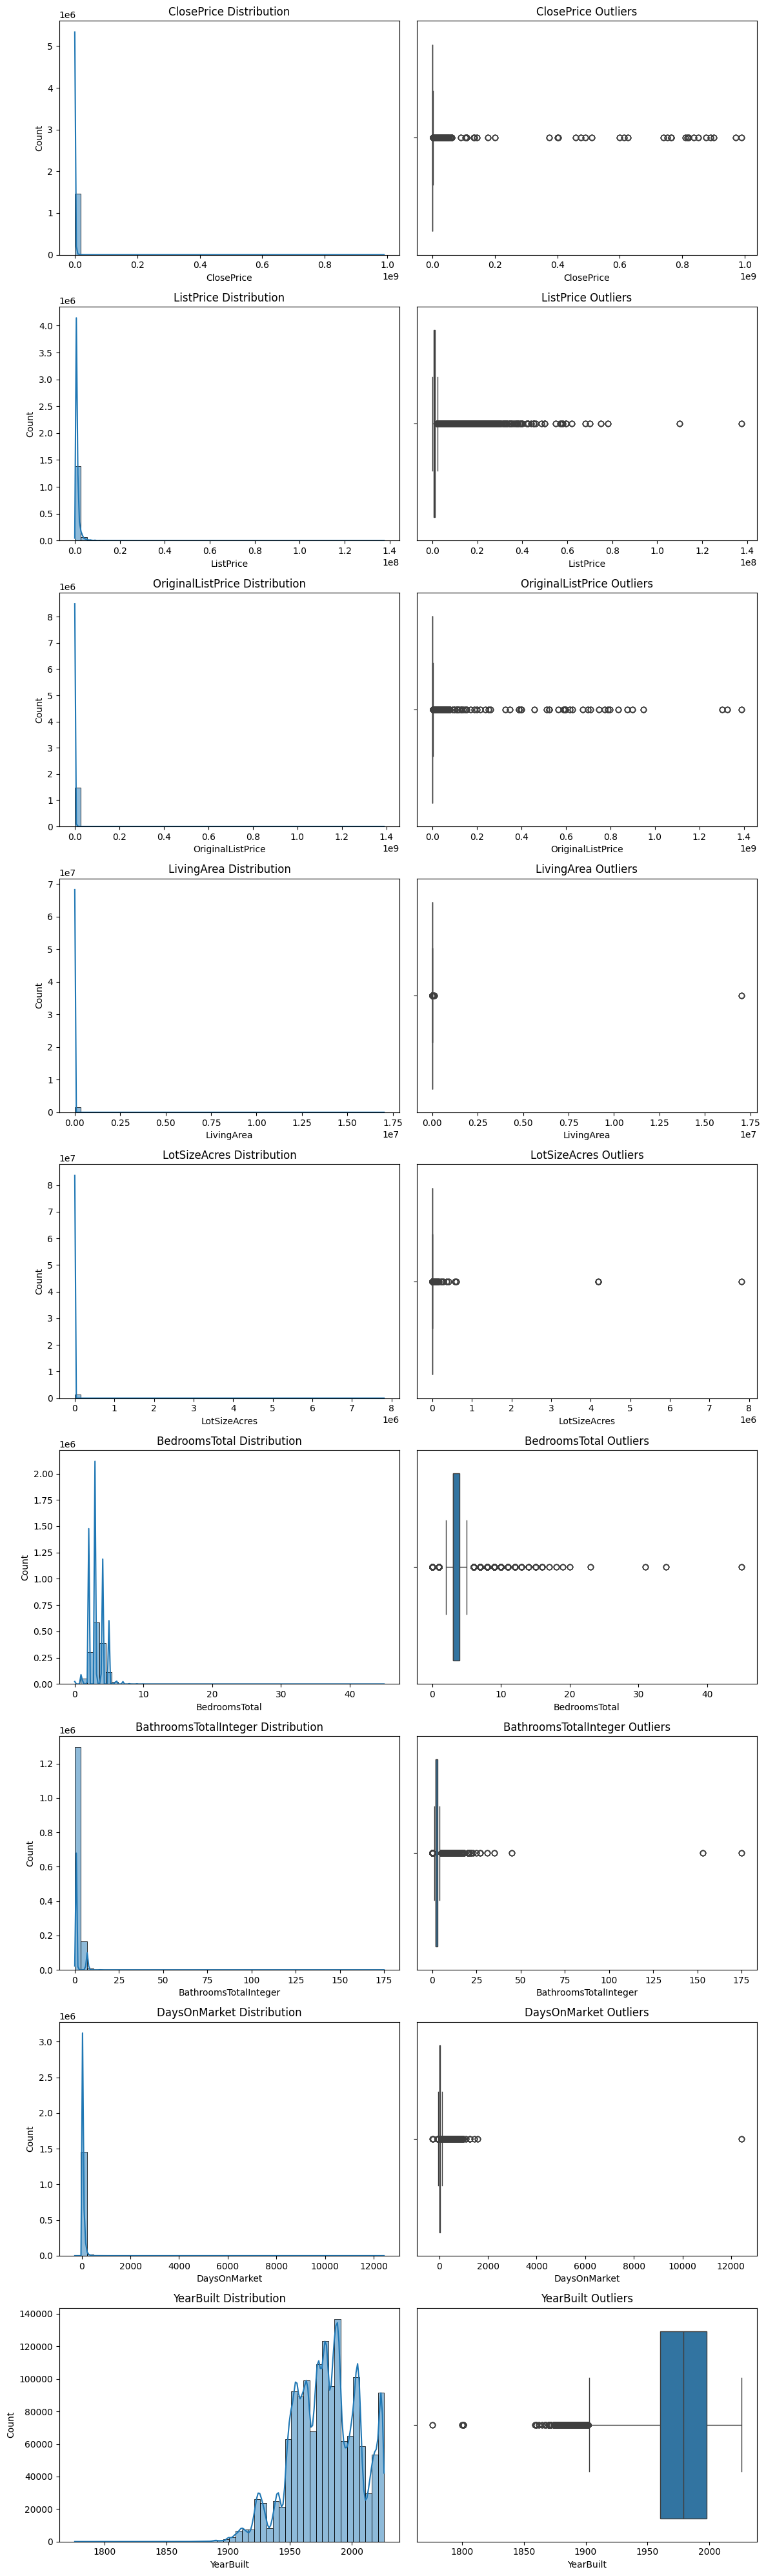

In [24]:
# Graphs
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(12,40))

for i, col in enumerate(core_numeric):
    # Histogram
    sns.histplot(sold_df[col],bins=50,kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(x=sold_df[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} Outliers')
plt.tight_layout()
plt.show()

### Mortgage Rate Enrichment

In [25]:
import pandas as pd

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])

# 2. Rename columns so 'observation_date' becomes 'date' for the pipeline
mortgage.columns = ['date', 'rate_30yr_fixed']

# 3. Resample weekly rates to monthly averages
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = mortgage.groupby('year_month')['rate_30yr_fixed'].mean().reset_index()

# 4. Create a matching year_month key on the Sold dataset using CloseDate
sold_df['year_month'] = pd.to_datetime(sold_df['CloseDate']).dt.to_period('M')

# 5. Merge the dataframes together
sold_with_rates_df = sold_df.merge(mortgage_monthly, on='year_month', how='left')

# 6. Check for missing values and preview the success
print(f"Null mortgage rates: {sold_with_rates_df['rate_30yr_fixed'].isnull().sum()}")
print("\nPreview of the enriched dataset:")
print(sold_with_rates_df[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

Null mortgage rates: 0

Preview of the enriched dataset:
    CloseDate year_month  ClosePrice  rate_30yr_fixed
0  2026-02-27    2026-02   2299000.0           6.0475
1  2026-02-27    2026-02   1100000.0           6.0475
2  2026-02-27    2026-02    938000.0           6.0475
3  2026-02-24    2026-02    525000.0           6.0475
4  2026-02-27    2026-02    240000.0           6.0475


## Data Cleaning and Preparation

In [26]:
# Convert data fields to datetime format
date_cols = ['CloseDate','ListingContractDate','PurchaseContractDate','ContractStatusChangeDate']
for col in date_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col]= pd.to_datetime(sold_with_rates_df[col])


In [27]:
# Check for duplicates
sold_with_rates_df[sold_with_rates_df.duplicated(subset='ListingKey')]
sold_with_rates_df = sold_with_rates_df.drop_duplicates(subset=['ListingKey'], keep='last') # Keep the most recent property with the listing key

In [28]:
# Drop rows if missing critical value
must_columns = ['ListingKey', 'ClosePrice', 'CloseDate', 'City']
sold_with_rates_df = sold_with_rates_df.dropna(subset=must_columns)

In [29]:
# Fill in missing counts with '0'
zero_fill_cols = ['GarageSpaces', 'ParkingTotal', 'FireplacesTotal']

for col in zero_fill_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(0)

# Fill in missing Yes/No features with 'No'
fill_no_cols = ['PoolPrivateYN', 'ViewYN', 'CoolingYN', 'HeatingYN']
for col in fill_no_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(False)

# Fill in missing categorical data with "Unknown"
cat_fill_cols = ['ArchitectureStyle', 'Heating', 'Cooling', 'WaterSource']
for col in cat_fill_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna('Unknown')

# Fill in missing numerical values
num_fill_cols = ['LotSizeArea', 'YearBuilt']
for col in num_fill_cols:
    if col in sold_with_rates_df.columns:
        col_median = sold_with_rates_df[col].median()
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(col_median)


In [30]:
# Drop missing Living Area
sold_with_rates_df = sold_with_rates_df.dropna(subset='LivingArea')
# Filter out where Living Area is less than 0
sold_with_rates_df = sold_with_rates_df[sold_with_rates_df['LivingArea'] > 0]

In [34]:
# Remove rows with invalid numeric values
sold_with_rates_df = sold_with_rates_df[(sold_with_rates_df['ClosePrice'] > 0) & (sold_with_rates_df['LivingArea'] > 0) & (sold_with_rates_df['DaysOnMarket'] >= 0) & (sold_with_rates_df['BedroomsTotal'] >= 0) & (sold_with_rates_df['BathroomsTotalInteger'] >= 0)]

In [35]:
# Data consistency checks
sold_with_rates_df['listing_after_close_flag'] = sold_with_rates_df['ListingContractDate'] < sold_with_rates_df['PurchaseContractDate']
sold_with_rates_df['purchase_after_close_flag'] = sold_with_rates_df['PurchaseContractDate'] > sold_with_rates_df['ListingContractDate']
sold_with_rates_df['negative_timeline_flag'] = sold_with_rates_df['DaysOnMarket'] < 0


In [36]:
# Geographic Data Checks
sold_with_rates_df['missing_coords'] = sold_with_rates_df['Latitude'].isnull() | sold_with_rates_df['Longitude'].isnull()
sold_with_rates_df['sentinel_coords'] = (sold_with_rates_df['Latitude'] == 0) | (sold_with_rates_df['Longitude'] == 0)
sold_with_rates_df['cal_coords'] = sold_with_rates_df['Longitude'] > 0
sold_with_rates_df

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,latfilled,lonfilled,year_month,rate_30yr_fixed,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,missing_coords,sentinel_coords,cal_coords
1102758,Mlslistings,Mlslistings,Wood,False,False,NaN,1156843715,2026-02-27,2299000.0,Debra,...,NaN,NaN,2026-02,6.0475,False,False,False,False,False,False
1102759,OrangeCounty,OrangeCounty,"Carpet,Tile",False,False,1100000.0,1155620121,2026-02-27,1100000.0,Senka,...,NaN,NaN,2026-02,6.0475,True,True,False,False,False,False
1102760,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,False,False,999000.0,1155350576,2026-02-27,938000.0,Hosh,...,NaN,NaN,2026-02,6.0475,True,True,False,False,False,False
1102761,Newport,Newport,NaN,False,False,525000.0,1155192177,2026-02-24,525000.0,Dustin,...,NaN,NaN,2026-02,6.0475,False,False,False,False,False,False
1102762,Mrmls,SierraNorthValley,NaN,True,False,299000.0,1155179209,2026-02-27,240000.0,Marty,...,NaN,NaN,2026-02,6.0475,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470339,NorthSanLuisObispo,NorthSanLuisObispo,"Carpet,Laminate",True,False,899900.0,1035678879,2025-12-17,600000.0,Carolynne,...,NaN,NaN,2025-12,6.1900,True,True,False,False,False,False
1470340,TheInlandGateway,TheInlandGateway,NaN,True,False,494900.0,1035520905,2025-12-15,380000.0,Brian L.,...,NaN,NaN,2025-12,6.1900,True,True,False,False,False,False
1470341,Mlslistings,Mlslistings,"Carpet,Tile",True,False,800000.0,1016494723,2025-12-15,365896.0,Joan,...,NaN,NaN,2025-12,6.1900,True,True,False,False,False,False
1470342,PacificWest,PacificWest,Wood,False,False,1150000.0,535503977,2025-12-19,564000.0,Hemal,...,NaN,NaN,2025-12,6.1900,True,True,False,False,False,False


## Feature Engineering and Market Metrics

In [37]:
sold_with_rates_df['PriceRatio'] = sold_with_rates_df['ClosePrice'] / sold_with_rates_df['OriginalListPrice'] # Measures negotiation strength
sold_with_rates_df['PricePerSqFt'] = sold_with_rates_df['ClosePrice'] / sold_with_rates_df['LivingArea'] # Normalizes price across sizes
sold_with_rates_df['Year'] = sold_with_rates_df['CloseDate'].dt.year # Enable time-series analysis
sold_with_rates_df['Month'] = sold_with_rates_df['CloseDate'].dt.month # Enable time-series analysis
sold_with_rates_df['YrMo'] = sold_with_rates_df['CloseDate'].dt.to_period('M').astype(str) # Enable time-series analysis
sold_with_rates_df['CloseToOriginalListRatio'] = sold_with_rates_df['ClosePrice'] / sold_with_rates_df['OriginalListPrice'] # Captures full price reduction history
sold_with_rates_df['ListingToContractDays'] = sold_with_rates_df['PurchaseContractDate'] - sold_with_rates_df['ListingContractDate'] # Measures time from listing to accepted offer
sold_with_rates_df['ContractToCloseDays'] = sold_with_rates_df['CloseDate'] - sold_with_rates_df['PurchaseContractDate'] # Escrow and closing period duration




## Outlier Detection and Data Quality

In [38]:
Q1 = sold_with_rates_df['ClosePrice'].quantile(0.25)
Q3 = sold_with_rates_df['ClosePrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1- 1.5 * IQR
upper = Q3 + 1.5 * IQR

sold__with_rates_df = sold_with_rates_df[(sold_with_rates_df['ClosePrice'] >= lower) & (sold_with_rates_df['ClosePrice'] <= upper)]

## Export to CSV for Tableau